In [10]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
print("Размер x_train:", x_train.shape)
print("Размер y_train:", y_train.shape)
print("Размер x_test:", x_test.shape)
print("Размер y_test:", y_test.shape)

Размер x_train: (60000, 28, 28)
Размер y_train: (60000,)
Размер x_test: (10000, 28, 28)
Размер y_test: (10000,)


In [6]:
x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


In [8]:
print(x_train.shape, y_train.shape)

(60000, 28, 28, 1) (60000, 10)


In [ ]:
# model = Sequential([
#     Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
#     MaxPooling2D(pool_size=(2, 2)),
#     Conv2D(64, kernel_size=(3, 3), activation='relu'),
#     MaxPooling2D(pool_size=(2, 2)),
#     Flatten(),
#     Dense(128, activation='relu'),
#     Dropout(0.3),
#     Dense(10, activation='softmax')
# ])    

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

In [12]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(x_train, y_train, epochs=5, batch_size=128, validation_split=0.2)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9161 - loss: 0.2770 - val_accuracy: 0.9763 - val_loss: 0.0766
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9760 - loss: 0.0795 - val_accuracy: 0.9827 - val_loss: 0.0553
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9821 - loss: 0.0582 - val_accuracy: 0.9868 - val_loss: 0.0462
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9864 - loss: 0.0443 - val_accuracy: 0.9878 - val_loss: 0.0407
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9883 - loss: 0.0378 - val_accuracy: 0.9887 - val_loss: 0.0397


In [14]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Точность на тестовом наборе:", test_acc)
print("Потеря на тестовом наборе:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9899 - loss: 0.0292
Точность на тестовом наборе: 0.9898999929428101
Потеря на тестовом наборе: 0.029183654114603996


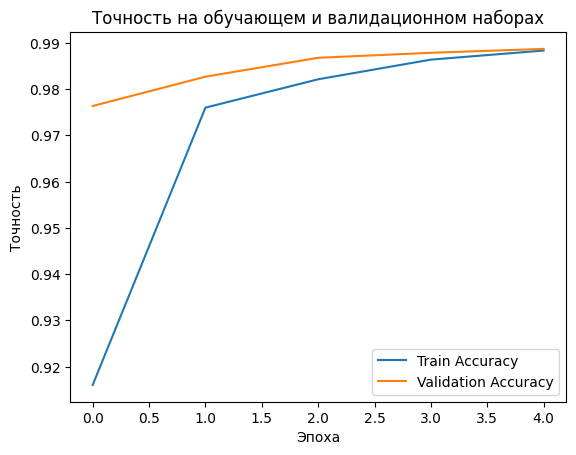

In [16]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.title("Точность на обучающем и валидационном наборах")
plt.legend()
plt.show()

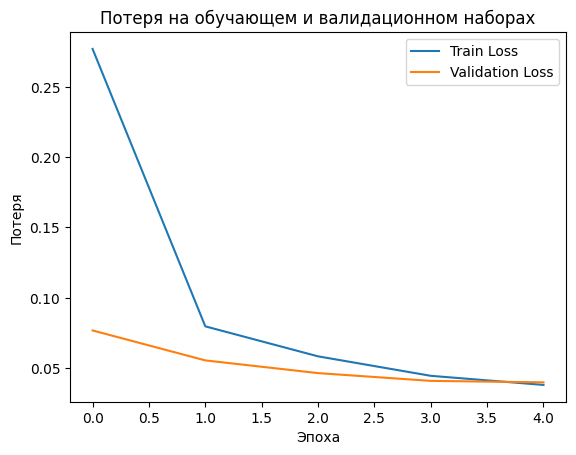

In [17]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Эпоха')
plt.ylabel('Потеря')
plt.title("Потеря на обучающем и валидационном наборах")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step
Предсказанный класс: 7, Истинный класс: 7


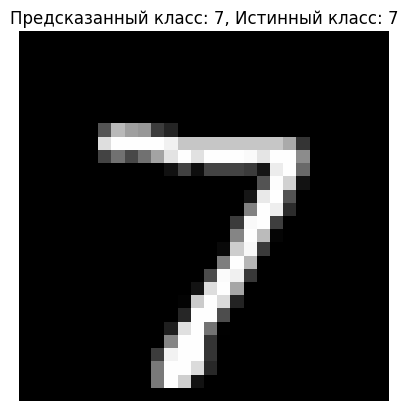

In [18]:
index = 0

image = x_test[index]
prediction = model.predict(image.reshape(1, 28, 28, 1))

predicted_class = np.argmax(prediction)
true_class = np.argmax(y_test[index])

print(f"Предсказанный класс: {predicted_class}, Истинный класс: {true_class}")

plt.imshow(image.reshape(28, 28), cmap='gray')
plt.title(f"Предсказанный класс: {predicted_class}, Истинный класс: {true_class}")
plt.axis('off')
plt.show()

В данной работе была реализована сверточная нейронная сеть для классификации рукописных цифр из датасета MNIST. Данные были загружены с помощью tensorflow.keras.datasets.mnist. Значения пикселей изображений были нормализованы путем деления на 255, что позволило привести их к диапазону от 0 до 1. Метки классов были преобразованы в формат one-hot encoding.

Модель CNN состоит из сверточных слоев Conv2D, слоев подвыборки MaxPooling2D, слоя Flatten и полносвязных слоев Dense. В качестве оптимизатора использовался Adam, функция потерь — Categorical Crossentropy, а основной метрикой качества — Accuracy. После обучения модель была протестирована на тестовой выборке и показала высокую точность классификации рукописных цифр.

In [21]:
save_dir = "/content/drive/MyDrive/models/mnist_cnn_model"

os.makedirs(save_dir, exist_ok=True)
model.save(os.path.join(save_dir, "mnist_cnn_model.keras"))

In [23]:
from tensorflow.keras.models import load_model

model_path = "/content/drive/MyDrive/models/mnist_cnn_model/mnist_cnn_model.keras"

loaded_model = load_model(model_path, compile=False)

print("Модель успешно загружена из:", model_path)

Модель успешно загружена из: /content/drive/MyDrive/models/mnist_cnn_model/mnist_cnn_model.keras


In [25]:
loaded_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
loaded_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
test_loss, test_acc = loaded_model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9899 - loss: 0.0292
Test Loss: 0.029183654114603996
Test Accuracy: 0.9898999929428101


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


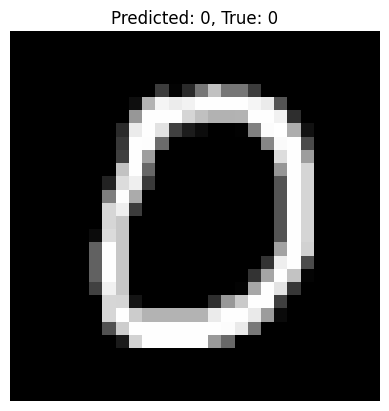

Предсказанный класс: 0
Правильный класс: 0


In [29]:
index = 10

image = x_test[index]

prediction = loaded_model.predict(image.reshape(1, 28, 28, 1))

predicted_class = np.argmax(prediction)
true_class = np.argmax(y_test[index])

plt.imshow(image.reshape(28, 28), cmap='gray')
plt.title(f"Predicted: {predicted_class}, True: {true_class}")
plt.axis('off')
plt.show()

print("Предсказанный класс:", predicted_class)
print("Правильный класс:", true_class)